In [1]:
import pandas as pd
import numpy as np

# Import the synthetic load-cell data
df = pd.read_csv('compression_test_data.csv')

# Define standard microneedle physical dimensions
original_height_mm = 1.0  
cross_sectional_area_mm2 = 0.15  

#Calculate Engineering Stress (Force / Area)
#1 N/mm^2 is equivalent to 1 MegaPascal (MPa)
df['Stress_MPa'] = df['Force_N'] / cross_sectional_area_mm2

#Calculate Engineering Strain (Deformation / Original Height)
df['Strain'] = df['Displacement_mm'] / original_height_mm

#Display the updated DataFrame
df.head()

#Display the table visually (first five terms) 
print(df.head())

# How many rows/columns Pandas successfully read
print(df.info())

  Batch_ID  Sample_ID  Force_N  Displacement_mm  Stress_MPa  Strain
0    Lot_A          1     21.5             0.11  143.333333    0.11
1    Lot_A          2     18.9             0.24  126.000000    0.24
2    Lot_A          3     25.7             0.27  171.333333    0.27
3    Lot_A          4     21.2             0.43  141.333333    0.43
4    Lot_A          5     16.0             0.21  106.666667    0.21
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Batch_ID         50 non-null     str    
 1   Sample_ID        50 non-null     int64  
 2   Force_N          50 non-null     float64
 3   Displacement_mm  50 non-null     float64
 4   Stress_MPa       50 non-null     float64
 5   Strain           50 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.7 KB
None


In [3]:
#Applying automated pass/fail logic to simulate "Verification & Validation" criteria -> establishing a threshold the plastic must withstand

#Define minimum stress patch must survive
min_yield_stress_mpa = 120.0

#Pass/Fail inspection with np.where()
df['QA_Status'] = np.where(df['Stress_MPa'] >= min_yield_stress_mpa, 'Pass', 'Fail')

#Yield Analysis to separate Lot_A from Lot_B
#Tally up the exact number of Passes and Fails per lot -> organize into clear table
qa_summary = df.groupby('Batch_ID')['QA_Status'].value_counts().unstack()

print(qa_summary)

QA_Status  Fail  Pass
Batch_ID             
Lot_A         8    17
Lot_B         8    17


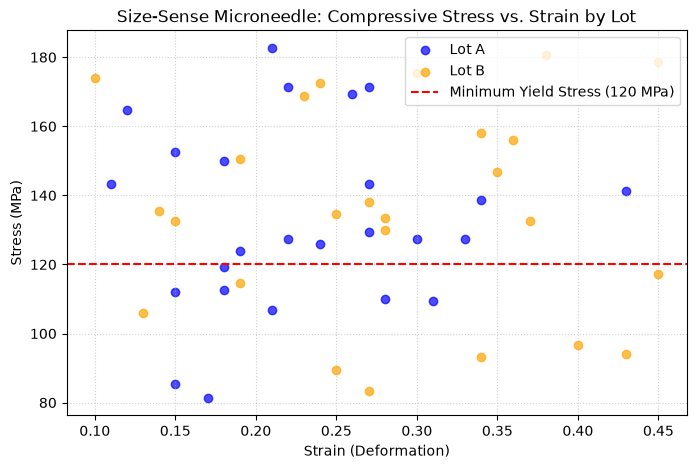

In [5]:
#Generate graph : regulatory safety threshold
import matplotlib.pyplot as plt

#Setting the canvas size
plt.figure(figsize=(8, 5))

#Filtering and plotting Lot A in blue
lot_a = df[df['Batch_ID'] == 'Lot_A']
plt.scatter(lot_a['Strain'], lot_a['Stress_MPa'], color= 'blue', label= 'Lot A', alpha=0.7)

#Filtering and plotting Lot B in orange
lot_b=df[df['Batch_ID'] == 'Lot_B']
plt.scatter(lot_b['Strain'], lot_b['Stress_MPa'], color= 'orange', label= 'Lot B', alpha=0.7)

#Adding the regulatorya acceptance threshold
plt.axhline(y=min_yield_stress_mpa, color= 'red', linestyle='--', label= 'Minimum Yield Stress (120 MPa)')

#Formatting the graph with labels
plt.title('Size-Sense Microneedle: Compressive Stress vs. Strain by Lot')
plt.xlabel('Strain (Deformation)')
plt.ylabel('Stress (MPa)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

#Displaying the final image
plt.show()